In [342]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [343]:
words = open('../names.txt').read().splitlines()

In [344]:
random.shuffle(words)

In [345]:
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
words_tr = words[:n1]
words_val = words[n1:n2]
words_test = words[n2:]

In [346]:
A = 27
alp = sorted(set(''.join(words)))
stoi = {c: i+1 for i, c in enumerate(alp)}
stoi['.'] = 0
itos = {v: k for k, v in stoi.items()}

In [347]:
block_size = 3
def build_dataset(ws):
    X = []
    Y = []
    for w in ws:
        context = [0] * block_size
        for c in w + '.':
            X.append(context)
            Y.append(stoi[c])
            context = context[1:]+[stoi[c]]
    return torch.tensor(X), torch.tensor(Y)

Xtr, Ytr = build_dataset(words_tr)
Xval, Yval = build_dataset(words_val)
Xtest, Ytest = build_dataset(words_test)

##### Initialization with normal distribution with small $std = 0.1$ to make all the logits approximately equal (so that from the very first epoch loss was about $log(1/27)$)

In [350]:
gen = torch.Generator().manual_seed(42)
embd_size = 10
layer_size = 300
E = torch.normal(mean = 0.0, std = 0.1, size = (A, embd_size),generator=gen)
W1 = torch.normal(mean = 0.0, std = 0.1, size =(embd_size * block_size, layer_size), generator=gen)
b1 = torch.normal(mean = 0.0, std = 0.1, size =(layer_size,), generator=gen)
W2 = torch.normal(mean = 0.0, std = 0.1, size =(layer_size, A), generator=gen)
b2 = torch.normal(mean = 0.0, std = 0.1, size =(A,), generator=gen)
params = [E, W1, b1, W2, b2]
sumparam = 0
for p in params:
    p.requires_grad = True
    sumparam += p.nelement()
sumparam

17697

In [351]:
stepi = []
lossi = []
lre = 10 ** torch.linspace(-4, 0, 1000)
iter = 0

In [361]:
lr = 10 ** -3
epochs = 100000
batch_size = 64
for e in range(epochs):
    batch = torch.randint(0, len(Xtr), (batch_size,))
    logits = (E[Xtr[batch]].view(-1, embd_size * block_size) @ W1 + b1).tanh() @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[batch])

    for p in params:
        p.grad = None

    lossi.append(loss.item())
    stepi.append(iter)
    iter += 1
    
    loss.backward()

    for p in params:
        p.data += -lr * p.grad
        #p.data += -lre[e] * p.grad

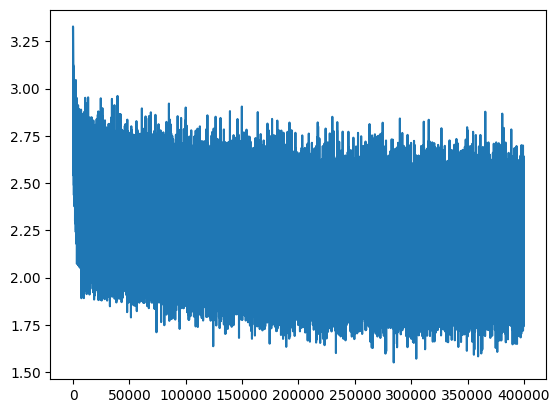

In [362]:
plt.plot(stepi, lossi);

In [363]:
logits = (E[Xtr].view(-1, embd_size * block_size) @ W1 + b1).tanh() @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.162198781967163

In [364]:
logits = (E[Xval].view(-1, embd_size * block_size) @ W1 + b1).tanh() @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss.item()

2.16611385345459

block size = 3, embd_size = 2, layer_size = 100, total_params = 3481: val_loss = 2.478

block size = 3, embd_size = 5, layer_size = 100, total_params = 4462: val_loss = 2.395

block size = 3, embd_size = 10, layer_size = 100, total_params = 6097: val_loss = 2.319

block size = 3, embd_size = 10, layer_size = 300, total_params = 17697: val_loss = 2.166

block size = 4, embd_size = 10, layer_size = 200, total_params = 13897: val_loss = 2.305

block size = 4, embd_size = 5, layer_size = 400, total_params = 19362: val_loss = 2.398

In [365]:
logits = (E[Xtest].view(-1, embd_size * block_size) @ W1 + b1).tanh() @ W2 + b2
loss = F.cross_entropy(logits, Ytest)
loss.item()

2.178659677505493

In [366]:
for _ in range(10):
    context = [0] * block_size
    name = ''
    while True:
        logits = (E[context].view(-1, embd_size * block_size) @ W1 + b1).tanh() @ W2 + b2
        probs = F.softmax(logits[0], dim = 0)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        name += itos[ix]
        context = context[1:]+[ix]
    print(name)

        

gerringleego
embelairdylenee
sarm
reiaan
men
aralyctreyven
elionna
anni
buwysley
mii
